# BERT FINE-TUNING
## Fine-Tuning Completo e Parcial do BERT

**Objetivo:**
1. Fine-Tuning Completo: treinar todas as camadas do BERT
2. Fine-Tuning Parcial: congelar camadas iniciais, treinar apenas finais
3. Comparar ambas abordagens
4. Matrizes de confusão e métricas
5. Comparação com todos os métodos anteriores

## 1. IMPORTAÇÕES

In [1]:
import sys
!{sys.executable} -m pip uninstall pyarrow -y
!{sys.executable} -m pip install pyarrow==12.0.1
!{sys.executable} -m pip install accelerate>=0.20.1
!{sys.executable} -m pip install transformers[torch]

Found existing installation: pyarrow 12.0.1
Uninstalling pyarrow-12.0.1:
  Successfully uninstalled pyarrow-12.0.1
  Using cached pyarrow-12.0.1-cp310-cp310-win_amd64.whl.metadata (3.1 kB)
Using cached pyarrow-12.0.1-cp310-cp310-win_amd64.whl (21.5 MB)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# BERT
import torch
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from torch.utils.data import Dataset

# Métricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Bibliotecas importadas!")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

✅ Bibliotecas importadas!
PyTorch: 2.0.1+cpu
CUDA: False


## 2. CARREGAR DADOS

In [3]:
df = pd.read_csv('../data/processed/reviews_balanceadas.csv')
df['label'] = df['sentimento'].map({'Positivo': 2, 'Neutro': 1, 'Negativo': 0})
df['texto_limpo'] = df['texto'].str.lower().str.strip()

print(f"Dataset: {len(df):,} reviews")
print(df['sentimento'].value_counts())

Dataset: 3,789 reviews
sentimento
Negativo    1263
Neutro      1263
Positivo    1263
Name: count, dtype: int64


## 3. DIVISÃO TREINO/TESTE

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['texto_limpo'].tolist(), df['label'].tolist(),
    test_size=0.2, random_state=42, stratify=df['label']
)

print(f"Treino: {len(X_train):,}")
print(f"Teste:  {len(X_test):,}")

Treino: 3,031
Teste:  758


## 4. DATASET CUSTOMIZADO

In [5]:
class ReviewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(texts, truncation=True, padding=True,
                                    max_length=max_length, return_tensors='pt')
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

print("✅ Dataset class definida!")

✅ Dataset class definida!


## 5. PREPARAR BERT

In [6]:
MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

train_dataset = ReviewsDataset(X_train, y_train, tokenizer)
test_dataset = ReviewsDataset(X_test, y_test, tokenizer)

print(f"✅ Datasets criados!")
print(f"   Treino: {len(train_dataset):,}")
print(f"   Teste:  {len(test_dataset):,}")

✅ Datasets criados!
   Treino: 3,031
   Teste:  758


## 6. FUNÇÃO DE MÉTRICAS

In [7]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec}

print("✅ Função de métricas definida!")

✅ Função de métricas definida!


## 7. FINE-TUNING COMPLETO

Treina **todas as camadas** do BERT.

In [8]:
print("="*80)
print("🔥 FINE-TUNING COMPLETO DO BERT")
print("="*80)

model_full = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

training_args_full = TrainingArguments(
    output_dir='../results/models/bert_full',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='../results/logs',
    logging_steps=50,
    evaluation_strategy="epoch",     
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2
)

trainer_full = Trainer(
    model=model_full,
    args=training_args_full,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\n🚀 Treinando BERT completo...")
print("⏱️  Pode demorar 30-60 min (GPU) ou 2-4h (CPU)\n")

trainer_full.train()

print("\n✅ Fine-Tuning Completo finalizado!")

🔥 FINE-TUNING COMPLETO DO BERT


Some weights of the model checkpoint at neuralmind/bert-base-portuguese-cased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the


🚀 Treinando BERT completo...
⏱️  Pode demorar 30-60 min (GPU) ou 2-4h (CPU)



  0%|          | 0/570 [00:00<?, ?it/s]

{'loss': 1.1121, 'learning_rate': 5e-06, 'epoch': 0.26}
{'loss': 1.0295, 'learning_rate': 1e-05, 'epoch': 0.53}
{'loss': 0.8253, 'learning_rate': 1.5e-05, 'epoch': 0.79}


...

{'eval_loss': 0.6994720101356506, 'eval_accuracy': 0.6926121372031663, 'eval_f1': 0.6841461815524276, 'eval_precision': 0.6841957252503467, 'eval_recall': 0.6926121372031663, 'eval_runtime': 225.2799, 'eval_samples_per_second': 3.365, 'eval_steps_per_second': 0.107, 'epoch': 1.0}
{'loss': 0.7061, 'learning_rate': 2e-05, 'epoch': 1.05}
{'loss': 0.6009, 'learning_rate': 2.5e-05, 'epoch': 1.32}
{'loss': 0.6487, 'learning_rate': 3e-05, 'epoch': 1.58}
{'loss': 0.6471, 'learning_rate': 3.5e-05, 'epoch': 1.84}


  0%|          | 0/24 [00:00<?, ?it/s]

{'eval_loss': 0.7192308902740479, 'eval_accuracy': 0.712401055408971, 'eval_f1': 0.7058710844504551, 'eval_precision': 0.7062855242575964, 'eval_recall': 0.712401055408971, 'eval_runtime': 187.6722, 'eval_samples_per_second': 4.039, 'eval_steps_per_second': 0.128, 'epoch': 2.0}
{'loss': 0.5725, 'learning_rate': 4e-05, 'epoch': 2.11}
{'loss': 0.467, 'learning_rate': 4.5e-05, 'epoch': 2.37}
{'loss': 0.5314, 'learning_rate': 5e-05, 'epoch': 2.63}
{'loss': 0.484, 'learning_rate': 1.4285714285714285e-05, 'epoch': 2.89}


  0%|          | 0/24 [00:00<?, ?it/s]

{'eval_loss': 0.7226502895355225, 'eval_accuracy': 0.7282321899736148, 'eval_f1': 0.725127902538436, 'eval_precision': 0.7237404964595865, 'eval_recall': 0.7282321899736148, 'eval_runtime': 211.1616, 'eval_samples_per_second': 3.59, 'eval_steps_per_second': 0.114, 'epoch': 3.0}
{'train_runtime': 7964.4159, 'train_samples_per_second': 1.142, 'train_steps_per_second': 0.072, 'train_loss': 0.6871358704148678, 'epoch': 3.0}

✅ Fine-Tuning Completo finalizado!


## 8. AVALIAR FINE-TUNING COMPLETO

In [9]:
predictions_full = trainer_full.predict(test_dataset)
preds_full = predictions_full.predictions.argmax(-1)
labels_full = predictions_full.label_ids

acc_full = accuracy_score(labels_full, preds_full)
prec_full, rec_full, f1_full, _ = precision_recall_fscore_support(
    labels_full, preds_full, average='weighted'
)

print("="*80)
print("📊 RESULTADOS - FINE-TUNING COMPLETO")
print("="*80)
print(f"   Acurácia:  {acc_full:.4f}")
print(f"   Precisão:  {prec_full:.4f}")
print(f"   Recall:    {rec_full:.4f}")
print(f"   F1-Score:  {f1_full:.4f}")

cm_full = confusion_matrix(labels_full, preds_full)

  0%|          | 0/24 [00:00<?, ?it/s]

📊 RESULTADOS - FINE-TUNING COMPLETO
   Acurácia:  0.7282
   Precisão:  0.7237
   Recall:    0.7282
   F1-Score:  0.7251


## 9. FINE-TUNING PARCIAL

Congela as **6 primeiras camadas**, treina apenas as últimas.

In [12]:
print("="*80)
print("🎯 FINE-TUNING PARCIAL DO BERT")
print("="*80)

model_partial = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

# Congelar embeddings
for param in model_partial.bert.embeddings.parameters():
    param.requires_grad = False

# Congelar primeiras 6 camadas
for i in range(6):
    for param in model_partial.bert.encoder.layer[i].parameters():
        param.requires_grad = False

print("✅ 6 primeiras camadas congeladas!")

training_args_partial = TrainingArguments(
    output_dir='../results/models/bert_partial',
    num_train_epochs=3,
    per_device_train_batch_size=8,       # ← REDUZI DE 16 PARA 8
    per_device_eval_batch_size=16,      # ← REDUZI DE 32 PARA 16
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=10                     # ← ADICIONEI PARA VER PROGRESSO
)

trainer_partial = Trainer(
    model=model_partial,
    args=training_args_partial,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("\n🚀 Treinando BERT parcial (batch reduzido)...")
print("⏱️  Tempo estimado: 1h30-2h\n")

trainer_partial.train()

print("\n✅ Fine-Tuning Parcial finalizado!")

🎯 FINE-TUNING PARCIAL DO BERT


Some weights of the model checkpoint at neuralmind/bert-base-portuguese-cased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the

✅ 6 primeiras camadas congeladas!

🚀 Treinando BERT parcial (batch reduzido)...
⏱️  Tempo estimado: 1h30-2h



  0%|          | 0/1137 [00:00<?, ?it/s]

{'loss': 1.0997, 'learning_rate': 4.956024626209323e-05, 'epoch': 0.03}
{'loss': 0.9996, 'learning_rate': 4.912049252418646e-05, 'epoch': 0.05}
{'loss': 0.8313, 'learning_rate': 4.8680738786279686e-05, 'epoch': 0.08}
{'loss': 0.7878, 'learning_rate': 4.824098504837291e-05, 'epoch': 0.11}
{'loss': 0.8172, 'learning_rate': 4.780123131046614e-05, 'epoch': 0.13}
{'loss': 0.6265, 'learning_rate': 4.736147757255937e-05, 'epoch': 0.16}
{'loss': 0.6575, 'learning_rate': 4.6921723834652596e-05, 'epoch': 0.18}
{'loss': 0.7346, 'learning_rate': 4.6481970096745824e-05, 'epoch': 0.21}
{'loss': 0.6475, 'learning_rate': 4.604221635883905e-05, 'epoch': 0.24}
{'loss': 0.7956, 'learning_rate': 4.560246262093228e-05, 'epoch': 0.26}
{'loss': 0.798, 'learning_rate': 4.516270888302551e-05, 'epoch': 0.29}
{'loss': 0.638, 'learning_rate': 4.4722955145118735e-05, 'epoch': 0.32}
{'loss': 0.5648, 'learning_rate': 4.428320140721196e-05, 'epoch': 0.34}
{'loss': 0.6667, 'learning_rate': 4.384344766930519e-05, 'epoc

...

{'eval_loss': 0.6583926677703857, 'eval_accuracy': 0.7084432717678101, 'eval_f1': 0.7081860495082557, 'eval_precision': 0.7100431592720918, 'eval_recall': 0.7084432717678101, 'eval_runtime': 202.1855, 'eval_samples_per_second': 3.749, 'eval_steps_per_second': 0.237, 'epoch': 1.0}
{'loss': 0.6711, 'learning_rate': 3.3289357959542656e-05, 'epoch': 1.0}
{'loss': 0.5917, 'learning_rate': 3.284960422163589e-05, 'epoch': 1.03}
{'loss': 0.6398, 'learning_rate': 3.240985048372912e-05, 'epoch': 1.06}
{'loss': 0.6472, 'learning_rate': 3.197009674582234e-05, 'epoch': 1.08}
{'loss': 0.5623, 'learning_rate': 3.1530343007915567e-05, 'epoch': 1.11}
{'loss': 0.59, 'learning_rate': 3.1090589270008794e-05, 'epoch': 1.13}
{'loss': 0.4438, 'learning_rate': 3.065083553210202e-05, 'epoch': 1.16}
{'loss': 0.4684, 'learning_rate': 3.021108179419525e-05, 'epoch': 1.19}
{'loss': 0.5232, 'learning_rate': 2.9771328056288477e-05, 'epoch': 1.21}
{'loss': 0.3101, 'learning_rate': 2.9331574318381705e-05, 'epoch': 1.2

  0%|          | 0/48 [00:00<?, ?it/s]

{'eval_loss': 0.7321687340736389, 'eval_accuracy': 0.7242744063324539, 'eval_f1': 0.7222457125037808, 'eval_precision': 0.7217609735186951, 'eval_recall': 0.7242744063324539, 'eval_runtime': 200.1127, 'eval_samples_per_second': 3.788, 'eval_steps_per_second': 0.24, 'epoch': 2.0}
{'loss': 0.4329, 'learning_rate': 1.6578715919085312e-05, 'epoch': 2.01}
{'loss': 0.3005, 'learning_rate': 1.613896218117854e-05, 'epoch': 2.03}
{'loss': 0.5743, 'learning_rate': 1.5699208443271768e-05, 'epoch': 2.06}
{'loss': 0.5779, 'learning_rate': 1.5259454705364995e-05, 'epoch': 2.08}
{'loss': 0.4336, 'learning_rate': 1.4819700967458225e-05, 'epoch': 2.11}
{'loss': 0.4354, 'learning_rate': 1.4379947229551453e-05, 'epoch': 2.14}
{'loss': 0.2499, 'learning_rate': 1.3940193491644679e-05, 'epoch': 2.16}
{'loss': 0.3627, 'learning_rate': 1.3500439753737906e-05, 'epoch': 2.19}
{'loss': 0.4714, 'learning_rate': 1.3060686015831136e-05, 'epoch': 2.22}
{'loss': 0.3155, 'learning_rate': 1.2620932277924363e-05, 'epoch

  0%|          | 0/48 [00:00<?, ?it/s]

{'eval_loss': 0.833284318447113, 'eval_accuracy': 0.7097625329815304, 'eval_f1': 0.7066355619003667, 'eval_precision': 0.7060559459589832, 'eval_recall': 0.7097625329815304, 'eval_runtime': 199.2281, 'eval_samples_per_second': 3.805, 'eval_steps_per_second': 0.241, 'epoch': 3.0}
{'train_runtime': 5769.1835, 'train_samples_per_second': 1.576, 'train_steps_per_second': 0.197, 'train_loss': 0.5613360142854609, 'epoch': 3.0}

✅ Fine-Tuning Parcial finalizado!


## 10. AVALIAR FINE-TUNING PARCIAL

In [13]:
predictions_partial = trainer_partial.predict(test_dataset)
preds_partial = predictions_partial.predictions.argmax(-1)
labels_partial = predictions_partial.label_ids

acc_partial = accuracy_score(labels_partial, preds_partial)
prec_partial, rec_partial, f1_partial, _ = precision_recall_fscore_support(
    labels_partial, preds_partial, average='weighted'
)

print("="*80)
print("📊 RESULTADOS - FINE-TUNING PARCIAL")
print("="*80)
print(f"   Acurácia:  {acc_partial:.4f}")
print(f"   Precisão:  {prec_partial:.4f}")
print(f"   Recall:    {rec_partial:.4f}")
print(f"   F1-Score:  {f1_partial:.4f}")

cm_partial = confusion_matrix(labels_partial, preds_partial)

  0%|          | 0/48 [00:00<?, ?it/s]

📊 RESULTADOS - FINE-TUNING PARCIAL
   Acurácia:  0.7243
   Precisão:  0.7218
   Recall:    0.7243
   F1-Score:  0.7222


## 11. MATRIZES DE CONFUSÃO

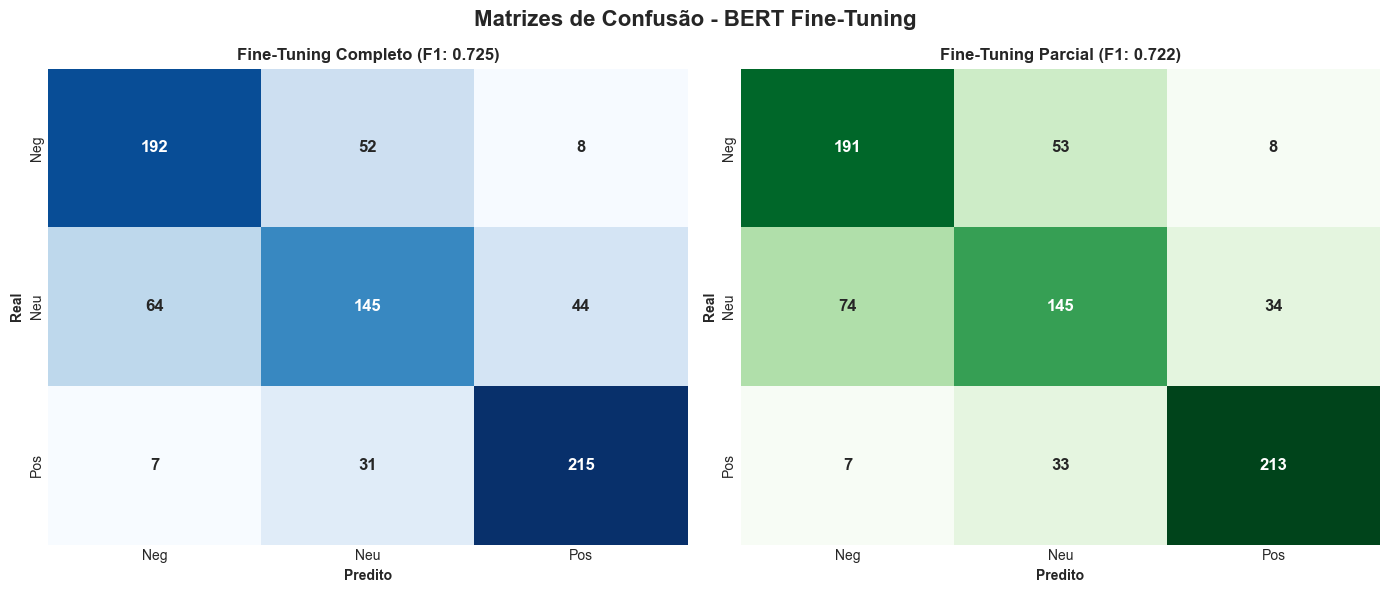

💾 Matrizes salvas!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Completo
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'],
            ax=axes[0], cbar=False, annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title(f'Fine-Tuning Completo (F1: {f1_full:.3f})', fontweight='bold')
axes[0].set_ylabel('Real', fontweight='bold')
axes[0].set_xlabel('Predito', fontweight='bold')

# Parcial
sns.heatmap(cm_partial, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'],
            ax=axes[1], cbar=False, annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_title(f'Fine-Tuning Parcial (F1: {f1_partial:.3f})', fontweight='bold')
axes[1].set_ylabel('Real', fontweight='bold')
axes[1].set_xlabel('Predito', fontweight='bold')

plt.suptitle('Matrizes de Confusão - BERT Fine-Tuning', fontsize=16, fontweight='bold')
plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/07_matrizes_bert_ft.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Matrizes salvas!")

## 12. COMPARAÇÃO FINAL

In [15]:
resultados_bert = pd.DataFrame([
    {'Abordagem': 'BERT Fine-Tuning Completo', 'Acurácia': acc_full, 
     'Precisão': prec_full, 'Recall': rec_full, 'F1-Score': f1_full},
    {'Abordagem': 'BERT Fine-Tuning Parcial', 'Acurácia': acc_partial,
     'Precisão': prec_partial, 'Recall': rec_partial, 'F1-Score': f1_partial}
])

print("="*80)
print("📊 COMPARAÇÃO: COMPLETO vs PARCIAL")
print("="*80)
display(resultados_bert)

# Salvar
os.makedirs('../results/metrics', exist_ok=True)
resultados_bert.to_csv('../results/metrics/07_metricas_bert_ft.csv', index=False)
print("\n💾 Métricas salvas!")

📊 COMPARAÇÃO: COMPLETO vs PARCIAL


,Abordagem,Acurácia,Precisão,Recall,F1-Score
0,BERT Fine-Tuning Completo,0.728232,0.723740,0.728232,0.725128
1,BERT Fine-Tuning Parcial,0.724274,0.721761,0.724274,0.722246



💾 Métricas salvas!


## 13. COMPARAÇÃO COM TODAS ABORDAGENS

🏆 COMPARAÇÃO FINAL - TODAS AS ABORDAGENS


,Abordagem,F1-Score
3,BERT Fine-Tuning Completo,0.725128
4,BERT Fine-Tuning Parcial,0.722246
2,BERT Emb (Gradient Boosting),0.704408
1,TF-IDF (Naive Bayes),0.648923
0,Lexical (SentiLex Puro),0.441308


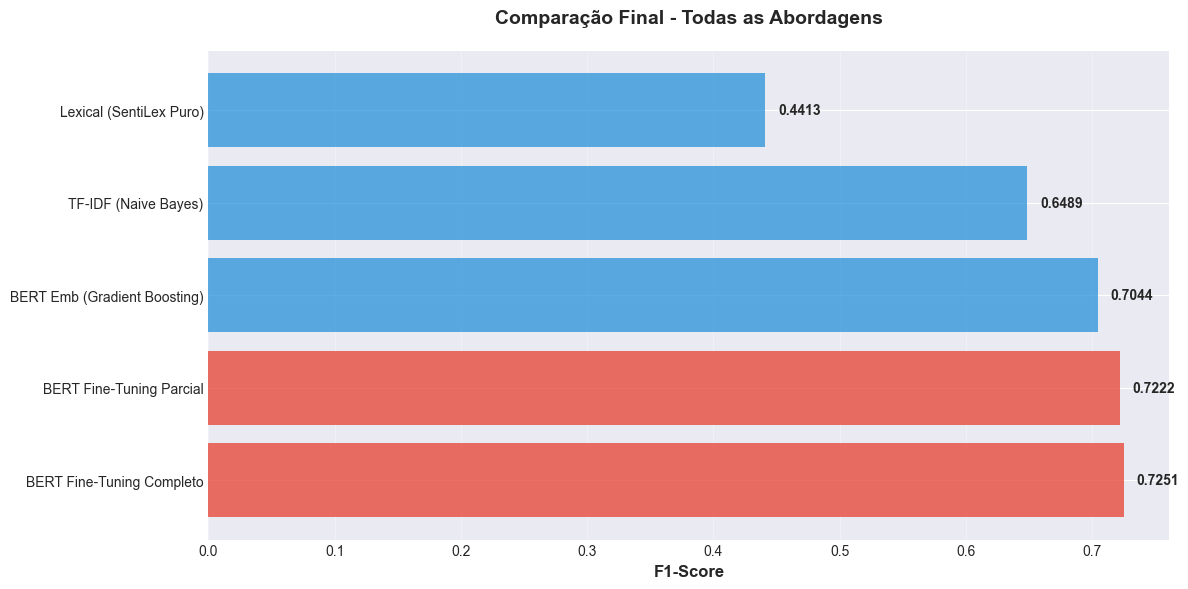


💾 Comparação final salva!


In [16]:
# Tentar carregar resultados anteriores
todas_abordagens = []

try:
    df_lex = pd.read_csv('../results/metrics/05_metricas_lexicais.csv')
    melhor_lex = df_lex.iloc[0]
    todas_abordagens.append({'Abordagem': f"Lexical ({melhor_lex['Método']})", 'F1-Score': melhor_lex['F1-Score']})
except:
    pass

try:
    df_tfidf = pd.read_csv('../results/metrics/04_metricas_tfidf.csv')
    melhor_tfidf = df_tfidf.iloc[0]
    todas_abordagens.append({'Abordagem': f"TF-IDF ({melhor_tfidf['Modelo']})", 'F1-Score': melhor_tfidf['F1-Score']})
except:
    pass

try:
    df_bert_emb = pd.read_csv('../results/metrics/06_metricas_bert_embeddings.csv')
    melhor_bert_emb = df_bert_emb.iloc[0]
    todas_abordagens.append({'Abordagem': f"BERT Emb ({melhor_bert_emb['nome']})", 'F1-Score': melhor_bert_emb['f1']})
except:
    pass

todas_abordagens.append({'Abordagem': 'BERT Fine-Tuning Completo', 'F1-Score': f1_full})
todas_abordagens.append({'Abordagem': 'BERT Fine-Tuning Parcial', 'F1-Score': f1_partial})

df_todas = pd.DataFrame(todas_abordagens).sort_values('F1-Score', ascending=False)

print("="*80)
print("🏆 COMPARAÇÃO FINAL - TODAS AS ABORDAGENS")
print("="*80)
display(df_todas)

# Visualização
plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if 'BERT Fine' in x else '#3498db' for x in df_todas['Abordagem']]
bars = plt.barh(df_todas['Abordagem'], df_todas['F1-Score'], color=colors, alpha=0.8)
plt.xlabel('F1-Score', fontweight='bold', fontsize=12)
plt.title('Comparação Final - Todas as Abordagens', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_todas['F1-Score']):
    plt.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/07_comparacao_final_todas.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n💾 Comparação final salva!")

## 14. SALVAR MODELOS

In [17]:
model_full.save_pretrained('../results/models/bert_full_final')
model_partial.save_pretrained('../results/models/bert_partial_final')
tokenizer.save_pretrained('../results/models/bert_tokenizer')

print("💾 Modelos BERT salvos!")
print("   • ../results/models/bert_full_final/")
print("   • ../results/models/bert_partial_final/")
print("   • ../results/models/bert_tokenizer/")

💾 Modelos BERT salvos!
   • ../results/models/bert_full_final/
   • ../results/models/bert_partial_final/
   • ../results/models/bert_tokenizer/


## 15. RESUMO FINAL

In [18]:
print("="*80)
print("📋 RESUMO NOTEBOOK 7 - BERT FINE-TUNING")
print("="*80)
print(f"\n✅ Duas abordagens de Fine-Tuning:")
print(f"   1. Completo (todas camadas): F1 = {f1_full:.4f}")
print(f"   2. Parcial (6 camadas congeladas): F1 = {f1_partial:.4f}")

print(f"\n🏆 Melhor abordagem geral: {df_todas.iloc[0]['Abordagem']}")
print(f"   F1-Score: {df_todas.iloc[0]['F1-Score']:.4f}")

print(f"\n📁 Arquivos gerados:")
print(f"   • ../results/models/bert_full_final/")
print(f"   • ../results/models/bert_partial_final/")
print(f"   • ../results/metrics/07_metricas_bert_ft.csv")
print(f"   • ../results/figures/07_*.png")

print(f"\n✅ TCC COMPLETO! Todos os 7 notebooks executados!")
print("="*80)

📋 RESUMO NOTEBOOK 7 - BERT FINE-TUNING

✅ Duas abordagens de Fine-Tuning:
   1. Completo (todas camadas): F1 = 0.7251
   2. Parcial (6 camadas congeladas): F1 = 0.7222

🏆 Melhor abordagem geral: BERT Fine-Tuning Completo
   F1-Score: 0.7251

📁 Arquivos gerados:
   • ../results/models/bert_full_final/
   • ../results/models/bert_partial_final/
   • ../results/metrics/07_metricas_bert_ft.csv
   • ../results/figures/07_*.png

✅ TCC COMPLETO! Todos os 7 notebooks executados!
